# CBOW + Self-Attention Word2Vec -- Embedding Exploration

Loads the trained model from `models/checkpoint_step290000.pt` and:

1. t-SNE projection of word embeddings to 2D, plotted.
2. Nearest-neighbor queries for a handful of Darija words.
3. Runs `Embeddings/intrinsic_eval/scripts/evaluate_embeddings.py`'s word-similarity
   and analogy evaluation against this model.

Only the `input_embeddings` table is used as "the word vectors" -- the
self-attention/FFN block only ever processed *context windows* during
training (see `model.py`'s docstring: "only the input one is kept as 'the
word vectors' after training", standard word2vec convention). Run via the
GPU venv's kernel (CPU is fine here -- this notebook is just embedding
lookups + sklearn, no training).

In [ ]:
from __future__ import annotations

import json
import random
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE

import arabic_reshaper

ROOT = Path.cwd().resolve()
if ROOT.name == "word2vec":
    WORD2VEC_DIR = ROOT
    ROOT = ROOT.parents[1]
else:
    WORD2VEC_DIR = ROOT / "Embeddings" / "word2vec"

sys.path.insert(0, str(WORD2VEC_DIR / "scripts"))
sys.path.insert(0, str(ROOT / "Tokenization"))
sys.path.insert(0, str(ROOT / "Embeddings" / "intrinsic_eval" / "scripts"))

from model import CBOWAttention  # noqa: E402
from tokenizer_utils import load_tokenizer  # noqa: E402

DATA_DIR = WORD2VEC_DIR / "data"
MODELS_DIR = WORD2VEC_DIR / "models"
CHECKPOINT = MODELS_DIR / "checkpoint_step635000.pt"

device = torch.device("cpu")  # embedding lookups only -- GPU not needed

# Arabic-safe label rendering. Tahoma/Arial must come before Segoe UI in the
# fallback list (Segoe UI doesn't render arabic_reshaper's presentation-form
# glyphs joined -- confirmed by a rendered comparison).
plt.rcParams["font.family"] = ["Tahoma", "Arial", "Segoe UI", "DejaVu Sans"]

ARABIC_RE = re.compile(r"[؀-ۿݐ-ݿࢠ-ࣿﭐ-﷿ﹰ-﻿]")
LATIN_RE = re.compile(r"[a-zA-ZÀ-ɏ]")


def render_label(text: str) -> str:
    """Reshape Arabic-script text into joined presentation-form glyphs for
    correct matplotlib display. Deliberately does NOT also apply
    bidi.get_display() -- verified by a direct rendered A/B test against
    several known words ("خدمة", "السلام عليكم"): this environment's
    matplotlib/font stack already lays reshaped RTL glyphs out correctly on
    its own, so get_display's extra reversal on top produces a fully
    backwards word ("خدمة" -> "ةمدخ"). get_display is the textbook fix for
    renderers with NO bidi awareness at all -- this one isn't that case."""
    if ARABIC_RE.search(text):
        return arabic_reshaper.reshape(text)
    return text


def script_of(text: str) -> str:
    has_ar = bool(ARABIC_RE.search(text))
    has_lat = bool(LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


In [10]:
# Load the tokenizer, checkpoint metadata, and the model.
meta = json.loads((DATA_DIR / "meta.json").read_text(encoding="utf-8"))
token_freq = {int(k): v for k, v in json.loads((DATA_DIR / "token_freq.json").read_text(encoding="utf-8")).items()}
tok = load_tokenizer(meta["tokenizer"]["key"], meta["tokenizer"]["vocab_size"])
vocab_size = meta["tokenizer"]["vocab_size_actual"]

ckpt = torch.load(CHECKPOINT, map_location=device)
ckpt_args = ckpt["args"]
print(f"Checkpoint: step={ckpt['step']:,}, epoch={ckpt.get('epoch', '?')}, args={ckpt_args}")

model = CBOWAttention(
    vocab_size=vocab_size,
    embed_dim=ckpt_args["embed_dim"],
    num_heads=ckpt_args["num_heads"],
    ff_dim=ckpt_args["ff_dim"],
).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

embedding_matrix = model.input_embeddings.weight.detach().cpu().numpy()  # (vocab_size, embed_dim)
print("embedding_matrix shape:", embedding_matrix.shape)

PAD_ID = 0  # verified against Tokenization/models/bpe/bpe_20000/vocab.json

Checkpoint: step=565,000, epoch=18, args={'epochs': 1000, 'target_pairs_per_batch': 4096, 'lr': 0.002, 'num_negative': 5, 'embed_dim': 128, 'num_heads': 4, 'ff_dim': 512, 'log_every': 200, 'checkpoint_every': 5000, 'resume': '../models/checkpoint_step345000.pt'}
embedding_matrix shape: (20000, 128)


In [11]:
def get_word_vector(word: str) -> np.ndarray | None:
    """Word-level vector: BPE-encode the word, mean-pool the input embeddings
    of its piece(s). A single-token word (common for short/frequent Darija
    words) is just a direct table lookup; a multi-piece word is averaged --
    same convention used for OOV handling elsewhere in the repo's embedding
    eval tooling (evaluate_embeddings.py expects `str -> np.ndarray | None`).
    """
    ids = [i for i in tok.encode(word) if i != PAD_ID and i < vocab_size]
    if not ids:
        return None
    return embedding_matrix[ids].mean(axis=0)


# Sanity check
v = get_word_vector("\u0628\u0632\u0627\u0641")  # bezzaf ("a lot")
print("vector shape:", None if v is None else v.shape)

vector shape: (128,)


## 1. t-SNE projection to 2D

Two groups, plotted together but colored separately:
- **frequent corpus words** -- the top-N most common whitespace-split words
  in the training corpus (`rows.jsonl`'s cleaned `text`, not BPE pieces).
  Multi-token words get their vector from `get_word_vector` (mean of their
  BPE pieces' embeddings), same as any other word.
- **curated Darija words** -- every word appearing in the intrinsic-eval
  word-similarity/analogy sets.

In [ ]:
EVAL_DATA_DIR = ROOT / "Embeddings" / "intrinsic_eval" / "data"


def load_curated_words() -> list[str]:
    words: set[str] = set()
    with (EVAL_DATA_DIR / "word_similarity.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            words.add(row["word1"])
            
            words.add(row["word2"])
    with (EVAL_DATA_DIR / "analogy_pairs.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            cat = json.loads(line)
            for p in cat["pairs"]:
                words.add(p["word_a"])
                words.add(p["word_b"])
    return sorted(words)


curated_words = load_curated_words()
print(f"{len(curated_words)} unique curated words")


def count_corpus_words() -> "Counter[str]":
    """Word-level frequency count over the full corpus, splitting on
    whitespace (not BPE tokenization) -- per-word vectors already average
    BPE-piece embeddings via get_word_vector, so what's needed here is real
    corpus WORDS, matching how a person would split the text, not subword
    pieces."""
    from collections import Counter

    counts: Counter[str] = Counter()
    with (DATA_DIR / "rows.jsonl").open("r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            counts.update(json.loads(line)["text"].split())
            if (i + 1) % 1_000_000 == 0:
                print(f"  ...{i + 1:,} rows scanned")
    return counts


word_freq = count_corpus_words()
print(f"{len(word_freq):,} unique words across {sum(word_freq.values()):,} whitespace-split tokens")

TOP_N_FREQUENT_WORDS = 300  # more points in the plot itself
FREQUENT_WORD_POOL_SIZE = 10000  # candidate pool to sample from, each run

# Placeholders like [URL]/[MENTION] (see clean_text.py) and pure-digit/punctuation
# "words" aren't real vocabulary -- script_of() (arabic/latin) filters them out.
frequent_word_pool = [
    w for w, _ in word_freq.most_common(FREQUENT_WORD_POOL_SIZE * 3)
    if script_of(w) in ("arabic", "latin", "mixed")
][:FREQUENT_WORD_POOL_SIZE]

# Randomly sampled (no fixed seed) -- a different subset of the top
# FREQUENT_WORD_POOL_SIZE frequent words each time this cell runs, instead
# of always the exact same literal top-150. TSNE's own random_state below
# stays fixed -- that's about the projection algorithm's determinism given
# whatever points it's handed, not about which words get plotted.
frequent_words = random.sample(frequent_word_pool, min(TOP_N_FREQUENT_WORDS, len(frequent_word_pool)))
print(f"{len(frequent_words)} frequent corpus words (randomly sampled from top {len(frequent_word_pool)} by frequency)")

463 unique curated words


  ...1,000,000 rows scanned
  ...2,000,000 rows scanned
  ...3,000,000 rows scanned
  ...4,000,000 rows scanned
  ...5,000,000 rows scanned
3,906,731 unique words across 84,251,500 whitespace-split tokens
300 frequent corpus words (randomly sampled from top 10000 by frequency)


In [13]:
frequent_words_set = set(frequent_words)
curated_words_deduped = [w for w in curated_words if w not in frequent_words_set]

plot_vectors = []
plot_labels = []
plot_groups = []  # "frequent" or "curated"

for w in frequent_words:
    v = get_word_vector(w)
    if v is not None:
        plot_vectors.append(v)
        plot_labels.append(w)
        plot_groups.append("frequent")

for w in curated_words_deduped:
    v = get_word_vector(w)
    if v is not None:
        plot_vectors.append(v)
        plot_labels.append(w)
        plot_groups.append("curated")

X = np.stack(plot_vectors)
print(f"t-SNE input: {X.shape[0]} points, {X.shape[1]} dims")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
coords = tsne.fit_transform(X)

t-SNE input: 748 points, 128 dims


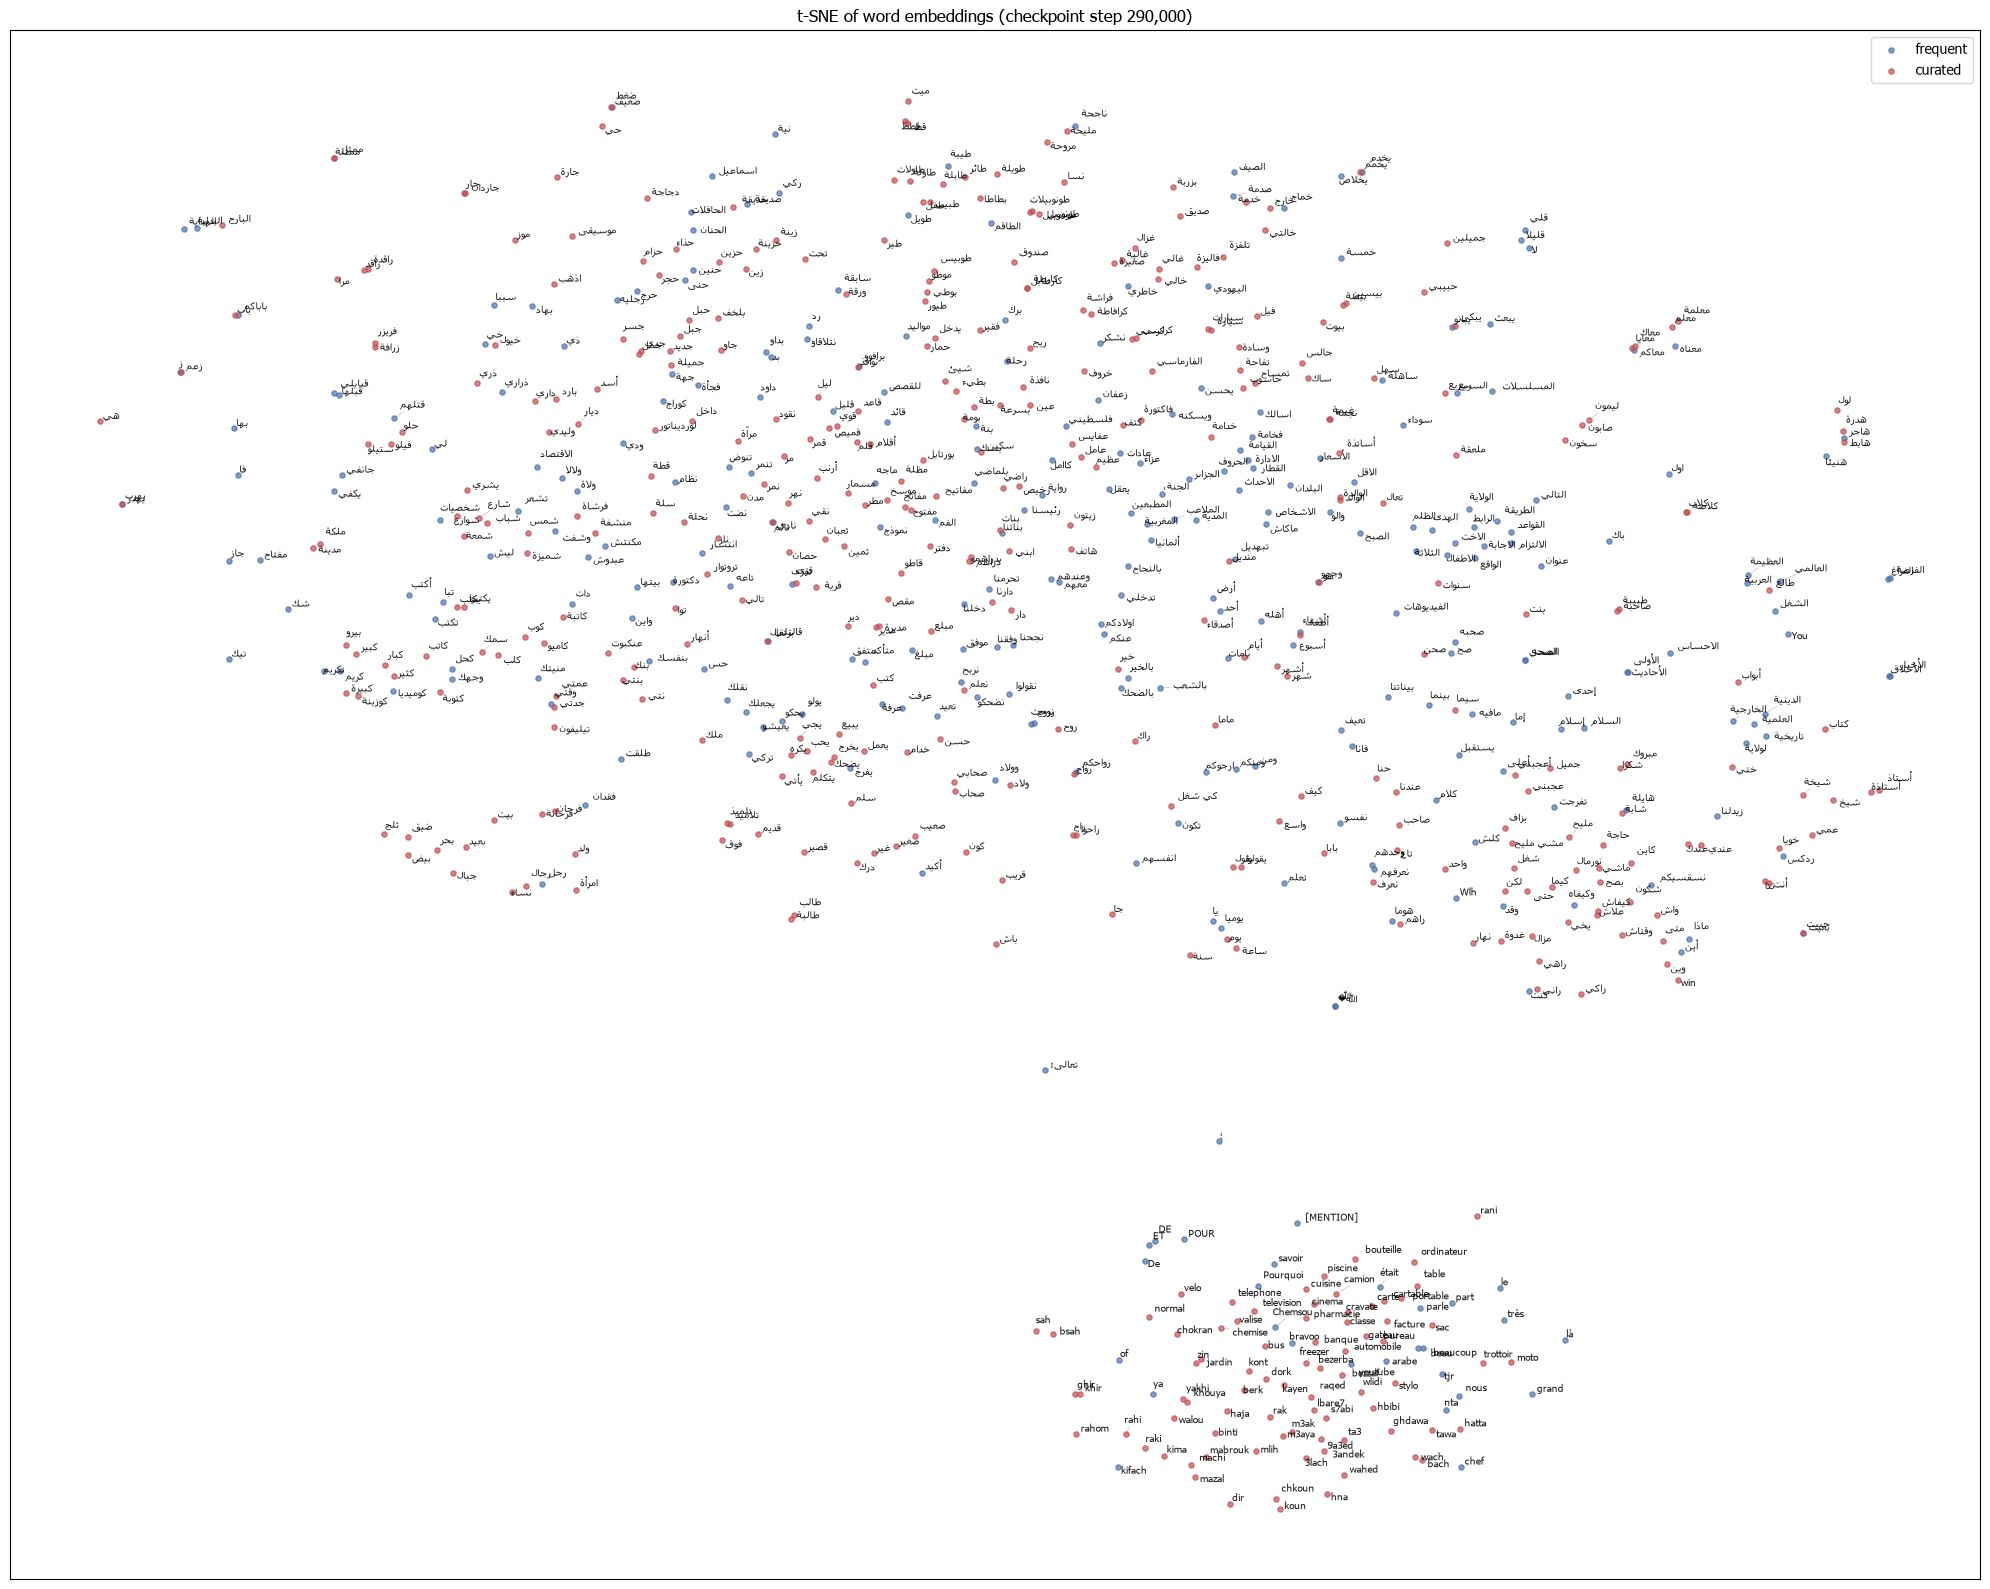

In [14]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(20, 16))

colors = {"frequent": "#4C72B0", "curated": "#C44E52"}
for group in ("frequent", "curated"):
    idx = [i for i, g in enumerate(plot_groups) if g == group]
    ax.scatter(coords[idx, 0], coords[idx, 1], s=14, color=colors[group], alpha=0.7, label=group)

# With ~600 points crammed into 2D, plain fixed-offset labels overlap and
# adjacent words visually merge into unreadable garbage (e.g. two labels
# sitting flush against each other read as one long fake "word"). adjustText
# repels overlapping labels apart and draws a thin line back to the true
# point, which plain annotate() offsets can't do.
texts = [
    ax.text(coords[i, 0], coords[i, 1], render_label(label), fontsize=7, alpha=0.9)
    for i, label in enumerate(plot_labels)
]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.4, alpha=0.6))

ax.set_title("t-SNE of word embeddings (checkpoint step 290,000)")
ax.legend()
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 2. Nearest neighbors

Candidate pool = curated words ∪ frequent corpus words (the same points
plotted above, all real space-split words -- see `get_word_vector`),
ranked by cosine similarity to the query word's vector.

In [15]:
pool_matrix = X  # reuse the same vectors gathered for the t-SNE plot
pool_words = plot_labels
pool_norms = np.linalg.norm(pool_matrix, axis=1, keepdims=True)
pool_normed = pool_matrix / np.clip(pool_norms, 1e-9, None)


def nearest_neighbors(word: str, k: int = 10) -> list[tuple[str, float]]:
    qv = get_word_vector(word)
    if qv is None:
        return []
    qv = qv / max(np.linalg.norm(qv), 1e-9)
    sims = pool_normed @ qv
    order = np.argsort(-sims)
    results: list[tuple[str, float]] = []
    for i in order:
        w = pool_words[i]
        if w == word:
            continue
        results.append((w, float(sims[i])))
        if len(results) >= k:
            break
    return results


demo_words = ["\u0628\u0632\u0627\u0641", "\u062e\u062f\u0645\u0629", "\u0648\u0627\u0634", "\u062d\u0628\u064a\u0628\u064a", "\u0645\u0644\u064a\u062d", "\u0648\u0644\u062f", "\u0628\u0646\u062a", "\u0632\u064a\u0646"]
# bezzaf, khedma, wach, hbibi, mlih, wled, bnt, zin

for w in demo_words:
    neighbors = nearest_neighbors(w, k=10)
    print(f"\n{w}:")
    for nw, score in neighbors:
        print(f"  {score:.3f}  {nw}")


بزاف:
  0.556  ماشي
  0.542  كلش
  0.528  مليح
  0.515  بصح
  0.510  مشي مليح
  0.504  كاين
  0.498  حاجة
  0.495  شابة
  0.486  بالشعب
  0.472  الاطفال

خدمة:
  0.803  صدمة
  0.766  خارج
  0.698  خماج
  0.602  يخدم
  0.594  يخلاص
  0.589  خالتي
  0.558  حزينة
  0.554  خاطري
  0.546  بزربة
  0.543  يخمم

واش:
  0.661  كيفاش
  0.610  وين
  0.595  علاش
  0.593  شكون
  0.578  كيما
  0.573  ماشي
  0.571  وقتاش
  0.568  نسقسيكم
  0.558  ماذا
  0.557  بصح

حبيبي:
  0.506  يبكي
  0.504  بيضة
  0.500  بيوت
  0.499  يعيشو
  0.488  خاطري
  0.472  يحب
  0.453  حبل
  0.451  صديق
  0.439  صاحبة
  0.435  طبيبة

مليح:
  0.635  بصح
  0.630  ماشي
  0.622  نورمال
  0.618  شابة
  0.595  حاجة
  0.592  حتى
  0.579  كاين
  0.577  شكرا
  0.574  علاش
  0.569  مشي مليح

ولد:
  0.621  رجل
  0.605  ولاد
  0.550  ضيق
  0.541  بيض
  0.522  بنت
  0.516  بحر
  0.516  وولاد
  0.512  رجال
  0.485  امرأة
  0.480  فرحانة

بنت:
  0.522  ولد
  0.506  ولاد
  0.475  ماشي
  0.468  كيما
  0.467  نعرف
  0.460  شابة
  0.452  ر

## 3. Intrinsic evaluation (`evaluate_embeddings.py`)

Same word-similarity (Spearman correlation) and analogy (vector-arithmetic
nearest-neighbor) evaluation used by `Embeddings/intrinsic_eval`, wired to
this trained model's `get_word_vector`.

In [16]:
from evaluate_embeddings import evaluate_similarity, evaluate_analogies

print("=== Word similarity (Spearman correlation) ===")
sim = evaluate_similarity(get_word_vector)
print(
    f"Overall: r={sim['overall_spearman']:.4f} (p={sim['overall_p_value']:.4f}), "
    f"n={sim['n_pairs_scored']}, oov={sim['n_pairs_oov']}"
)
for cat, r in sim["by_category"].items():
    print(f"  {cat:<24} r={r['spearman']:.4f}  n={r['n_pairs']}  oov={r['n_oov']}")

print("\n=== Analogies (vector-arithmetic nearest-neighbor accuracy) ===")
ana = evaluate_analogies(get_word_vector)
print(f"Overall: acc={ana['overall_accuracy']:.4f}, n={ana['overall_n_questions']}")
for cat, r in ana["by_category"].items():
    print(f"  {cat:<24} acc={r['accuracy']:.4f}  n={r['n_questions']}  skipped_oov={r['n_skipped_oov']}")

=== Word similarity (Spearman correlation) ===
Overall: r=-0.2488 (p=0.0002), n=215, oov=0
  synonym                  r=0.4990  n=31  oov=0
  antonym                  r=-0.0417  n=29  oov=0
  cross_script             r=0.4638  n=49  oov=0
  code_switch              r=-0.0761  n=30  oov=0
  morphological_variant    r=-0.2543  n=36  oov=0
  unrelated                r=0.1292  n=40  oov=0

=== Analogies (vector-arithmetic nearest-neighbor accuracy) ===
Overall: acc=0.1930, n=4290
  gender                   acc=0.3333  n=870  skipped_oov=0
  singular_plural          acc=0.3276  n=870  skipped_oov=0
  script_transliteration   acc=0.0992  n=2550  skipped_oov=0
